In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

In [11]:


# filename = "/Users/jkueny/data/HR4796a_lco2023a_magao-x_20230309_10/raws_20230310T054736_s_lyot_stop/camsci2/norm_lite_psflib/klip_fm_files/camsci2_z_20230309_10_klbasis.h5"
# filename = "/Users/jkueny/data/HR4796_rg_smlyot_20230312_13/raws_rg_smlyot_20230313T043914/camsci1/lite_psflib/klip_fm_files/camsci1_r_20230312_13_klbasis.h5"
# filename = "/Users/jkueny/data/HR4796_rg_smlyot_20230312_13/raws_rg_smlyot_20230313T043914/camsci2/lite_psflib/klip_fm_files/camsci2_g_20230312_13_klbasis.h5"
# filename = "/Users/jkueny/data/HR4796_rg_smlyot_20230312_13/raws_rg_smlyot_20230313T043914/camsci2/lite_psflib/wind_fm_files/camsci2_g_20230312_13_klbasis.h5"
filename = "/Users/jkueny/data/HR4796_lco20240328_29/raws_2x2binning_iz_smlyot/camsci2/lite_psflib/klip_fm_files/camsci2_z_20240328_29_klbasis.h5"


In [8]:
def _recursively_load_dict_contents_from_group(h5file, path):
    """
    Recursively explore the dictionnary for loading it

    Args:
        h5file: the file from which we load, opened with h5py.File
        path: the separator to aggregate the keys. Should be the same one used in
        _recursively_save_dict_contents_to_group
    Returns
        the rebuilt dictionnary
    """

    ans = {}
    for key, item in h5file[path].items():
        if isinstance(item, h5py._hl.dataset.Dataset):
            ans[key] = item[()]
        elif isinstance(item, h5py._hl.group.Group):
            ans[key] = _recursively_load_dict_contents_from_group(
                h5file, path + key + '/')
    return ans

In [9]:
def _load_dict_from_hdf5(filename):
    """
    Load a dictionnary from a h5 file

    Args:
        filename: the filename of the h5

    Returns:
        the dictionnary exctracted

    """

    with h5py.File(filename, "r") as h5file:
        return _recursively_load_dict_contents_from_group(h5file, '/')

In [10]:
klbasis = _load_dict_from_hdf5(filename)

#### KL basis file contents
+ `aligned_images_dict`
  - Library of aligned science PSF images.
  - Each of size (N_images, xdim * ydim)
    + e.g. (84, 50176) for z' band dataset.
  - Only 1 dict key "wl1000" b/c we use single wavelength cubes.
+ `evals_dict`
  - Assoc. eigenvalues
  - Each of size (1, N_KLmodes)?
  - Dict keys of section ids
    + Ex. idsec101i000 and idsec101i083
+ `evecs_dict`
  - Assoc. eigenvectors
  - Each of size (N_refimages, N_KLmodes)
  - Dict keys of section ids
    + Ex. idsec101i000 and idsec101i083
+ `input_img_num_dict`
  - This is just the literal image number in the sequence.
  - Results in 1 for idsec101i001 and 83 for idsec101i083, etc.
+ `klmodes_dict`
  - Each mode of (currently) unknown size.
    + for the z' dataset, each mode vector is (1,39112)
      - modes for each image is (2, 391112) because we only use 2 KL modes to subtract PSF.
  - Dict keys of section ids
    + Ex. idsec101i000 and idsec101i083
+ `klparam_dict`
  - Keys
    + ['IWA', 'OWA', 'PAs', 'aligned_center_x', 'aligned_center_y', 'input_img_shape', 'isRDI', 'nfiles', 'numbasis', 'nwvs', 'output_imgs_shape', 'wvs']
  - `input_img_shape = [224. 224.]` (ex.)
  - `output_img_shape = [84., 224., 224., 1]` (ex.)
    + (N_files, xdim, ydim, N_wvs)
+`ref_psfs_indicies_dict`
  - np array of integer indices for the images to use for the basis for a given image.
+ `section_ind_dict`
  - array indicies into the 2-D x-y image that correspond to a section.
    + As an example, for the HR4796 data we mask out pixels interior to the IWA and exterior to the OWA. This is our 1 section we care about.
    + This is why the number of elements in this array is less than the expected 224**2 = 50176
  - Size of one of these items is, e.g., (1,39112).
    + 224 square image, IWA 10, OWA 112

In [12]:
print(klbasis.keys())

dict_keys(['aligned_images_dict', 'evals_dict', 'evecs_dict', 'input_img_num_dict', 'klmodes_dict', 'klparam_dict', 'phiend_dict', 'phistart_dict', 'radend_dict', 'radstart_dict', 'ref_psfs_indicies_dict', 'section_ind_dict'])


In [17]:
print(klbasis['aligned_images_dict'].keys())
print(klbasis['aligned_images_dict']['wl1000'].shape)

dict_keys(['wl1000'])
(160, 50176)


In [9]:
print(klbasis['input_img_num_dict'].keys())

dict_keys(['idsec2790i000', 'idsec2790i001', 'idsec2790i002', 'idsec2790i003', 'idsec2790i004', 'idsec2790i005', 'idsec2790i006', 'idsec2790i007', 'idsec2790i008', 'idsec2790i009', 'idsec2790i010', 'idsec2790i011', 'idsec2790i012', 'idsec2790i013', 'idsec2790i014', 'idsec2790i015', 'idsec2790i016', 'idsec2790i017', 'idsec2790i018', 'idsec2790i019', 'idsec2790i020', 'idsec2790i021', 'idsec2790i022', 'idsec2790i023', 'idsec2790i024', 'idsec2790i025', 'idsec2790i026', 'idsec2790i027', 'idsec2790i028', 'idsec2790i029', 'idsec2790i030', 'idsec2790i031', 'idsec2790i032', 'idsec2790i033', 'idsec2790i034', 'idsec2790i035', 'idsec2790i036', 'idsec2790i037', 'idsec2790i038', 'idsec2790i039', 'idsec2790i040', 'idsec2790i041', 'idsec2790i042', 'idsec2790i043', 'idsec2790i044', 'idsec2790i045', 'idsec2790i046', 'idsec2790i047', 'idsec2790i048', 'idsec2790i049', 'idsec2790i050', 'idsec2790i051', 'idsec2790i052', 'idsec2790i053', 'idsec2790i054', 'idsec2790i055', 'idsec2790i056', 'idsec2790i057', 'id

In [10]:
sample_input_img_num = klbasis["input_img_num_dict"]["idsec101i000"]
print(sample_input_img_num)

KeyError: 'idsec101i000'

In [11]:
print(klbasis['section_ind_dict'].values())

dict_values([array([[ 2790,  2791,  2792, ..., 47383, 47384, 47385]]), array([[ 2790,  2791,  2792, ..., 47383, 47384, 47385]]), array([[ 2790,  2791,  2792, ..., 47383, 47384, 47385]]), array([[ 2790,  2791,  2792, ..., 47383, 47384, 47385]]), array([[ 2790,  2791,  2792, ..., 47383, 47384, 47385]]), array([[ 2790,  2791,  2792, ..., 47383, 47384, 47385]]), array([[ 2790,  2791,  2792, ..., 47383, 47384, 47385]]), array([[ 2790,  2791,  2792, ..., 47383, 47384, 47385]]), array([[ 2790,  2791,  2792, ..., 47383, 47384, 47385]]), array([[ 2790,  2791,  2792, ..., 47383, 47384, 47385]]), array([[ 2790,  2791,  2792, ..., 47383, 47384, 47385]]), array([[ 2790,  2791,  2792, ..., 47383, 47384, 47385]]), array([[ 2790,  2791,  2792, ..., 47383, 47384, 47385]]), array([[ 2790,  2791,  2792, ..., 47383, 47384, 47385]]), array([[ 2790,  2791,  2792, ..., 47383, 47384, 47385]]), array([[ 2790,  2791,  2792, ..., 47383, 47384, 47385]]), array([[ 2790,  2791,  2792, ..., 47383, 47384, 47385]]), a

In [14]:
print(klbasis['klmodes_dict'].keys())
print(len(klbasis['klmodes_dict']))

dict_keys(['idsec101i000', 'idsec101i001', 'idsec101i002', 'idsec101i003', 'idsec101i004', 'idsec101i005', 'idsec101i006', 'idsec101i007', 'idsec101i008', 'idsec101i009', 'idsec101i010', 'idsec101i011', 'idsec101i012', 'idsec101i013', 'idsec101i014', 'idsec101i015', 'idsec101i016', 'idsec101i017', 'idsec101i018', 'idsec101i019', 'idsec101i020', 'idsec101i021', 'idsec101i022', 'idsec101i023', 'idsec101i024', 'idsec101i025', 'idsec101i026', 'idsec101i027', 'idsec101i028', 'idsec101i029', 'idsec101i030', 'idsec101i031', 'idsec101i032', 'idsec101i033', 'idsec101i034', 'idsec101i035', 'idsec101i036', 'idsec101i037', 'idsec101i038', 'idsec101i039', 'idsec101i040', 'idsec101i041', 'idsec101i042', 'idsec101i043', 'idsec101i044', 'idsec101i045', 'idsec101i046', 'idsec101i047', 'idsec101i048', 'idsec101i049', 'idsec101i050', 'idsec101i051', 'idsec101i052', 'idsec101i053', 'idsec101i054', 'idsec101i055', 'idsec101i056', 'idsec101i057', 'idsec101i058', 'idsec101i059', 'idsec101i060', 'idsec101i061

In [30]:
sample_klmode = klbasis['klmodes_dict']["idsec101i000"]
print(sample_klmode)
print(sample_klmode.shape)

[[ 2.44269184e-04  2.62702799e-04  2.35131505e-04 ...  5.68677854e-04
   5.50126568e-04  5.62737693e-04]
 [ 3.56200948e-03  3.40091506e-03  3.75734775e-03 ... -4.53113206e-03
  -4.40372758e-03 -4.29477113e-03]
 [-1.72522937e-03 -1.83999859e-03 -2.18403907e-03 ...  1.29252345e-03
   1.69875757e-03  1.13757262e-03]
 ...
 [-1.83480458e-03 -7.62654295e-04 -7.95591180e-04 ...  2.04965818e-04
  -2.96385902e-04 -1.15988129e-03]
 [ 5.22481559e-04 -8.95111542e-05  2.25575760e-03 ...  7.46219347e-04
   4.03940452e-04  1.41106512e-03]
 [ 7.90061567e-04  2.04674271e-03  8.24836407e-04 ... -7.36907407e-04
  -2.93137218e-03 -1.79930149e-03]]
(35, 38888)


In [19]:
print(klbasis['klparam_dict'].keys())
print(klbasis["klparam_dict"]["isRDI"])
print(klbasis["klparam_dict"]["PAs"])
print(klbasis["klparam_dict"]["nfiles"])
print(klbasis["klparam_dict"]["numbasis"])

dict_keys(['IWA', 'OWA', 'PAs', 'aligned_center_x', 'aligned_center_y', 'input_img_shape', 'isRDI', 'nfiles', 'numbasis', 'nwvs', 'output_imgs_shape', 'wvs'])
1.0
[67.5412   66.8548   39.4174   33.1342   61.7597   61.1965   48.2586
 62.5781   67.8801   58.9847    9.56137  66.306    51.4561    8.00187
 68.656    35.9639    7.30327  30.4618   37.8598    1.19388  12.1714
 32.841    67.7675   37.0552   67.9931   60.7677   31.9604   68.874
 51.069    69.5181   61.4787   31.3635    9.93531  46.9805   30.7626
 62.0293   47.8381   68.2148   38.6514   59.4402   34.8051   11.0539
 68.3261   66.7371   66.5014    3.87379  39.1549   10.6835    3.49223
 32.2528   66.9701   38.3885   68.7664    8.80779  69.4115   48.4556
 29.8501    2.34544  52.4013    1.95757  51.2618   67.4269   68.9836
 12.5377   58.6787   68.5465   35.6877   50.2851   37.5918   67.6541
 60.6221    5.02181  59.2905   50.8757   52.0268   49.481    33.4225
  1.57355  48.664    49.2801   58.1333   66.6189   59.7408   50.6784
  5.4016

In [20]:
sample_klparam = klbasis['klparam_dict']["output_imgs_shape"]
print(sample_klparam)

[160. 224. 224.   1.]


In [20]:
sample_klparam = klbasis['klparam_dict']["PAs"]
print(sample_klparam)
print(len(sample_klparam))

[-60.3232   -59.4925   -58.497    -57.4985   -56.4135   -55.4987
 -54.4968   -53.4972   -52.497    -51.4985   -50.4994   -49.4987
 -48.4987   -47.4917   -46.4991   -45.4989   -44.4959   -43.492
 -42.4948   -41.4961   -40.4986   -39.4999   -38.4955   -37.4972
 -36.4996   -35.4981   -34.498    -33.4983   -32.495    -31.4923
 -30.4965   -29.4991   -28.4939   -27.4889   -26.4883   -25.4266
 -24.4836   -23.4963   -22.4979   -21.4977   -20.4958   -19.4976
 -18.4998   -17.4981   -16.4987   -15.4993   -14.4912   -13.4939
 -12.4981   -11.4885   -10.4979    -9.49475   -8.47782   -7.49186
  -6.49384   -5.49664   -4.49177   -3.49142   -2.49549   -1.49864
  -0.994479   1.0032     2.00063    3.00104    4.00169    5.00695
   6.00582    7.0065     8.00116    9.00256   10.0035    11.0009
  12.0034    13.0001    14.018     15.0045    16.0053    17.0052
  18.0027    19.0006    20.0022    21.0032    22.0008    23.0023
  24.0018    25.0009    26.0027    27.0009    28.0039    29.0039
  30.0038    31.0042   

In [21]:
sample_val = klbasis["aligned_images_dict"]['wl1000']
print(sample_val.shape)

(160, 50176)


In [22]:
sample_klmode = klbasis['klmodes_dict']['idsec101i001']
print(sample_klmode.shape)

(35, 38888)


In [23]:
sample_klmode = klbasis['wdhPAs_dict'].keys()
print(sample_klmode)

KeyError: 'wdhPAs_dict'

In [37]:
print(klbasis['evals_dict'].keys())

dict_keys(['idsec101i000', 'idsec101i001', 'idsec101i002', 'idsec101i003', 'idsec101i004', 'idsec101i005', 'idsec101i006', 'idsec101i007', 'idsec101i008', 'idsec101i009', 'idsec101i010', 'idsec101i011', 'idsec101i012', 'idsec101i013', 'idsec101i014', 'idsec101i015', 'idsec101i016', 'idsec101i017', 'idsec101i018', 'idsec101i019', 'idsec101i020', 'idsec101i021', 'idsec101i022', 'idsec101i023', 'idsec101i024', 'idsec101i025', 'idsec101i026', 'idsec101i027', 'idsec101i028', 'idsec101i029', 'idsec101i030', 'idsec101i031', 'idsec101i032', 'idsec101i033', 'idsec101i034', 'idsec101i035', 'idsec101i036', 'idsec101i037', 'idsec101i038', 'idsec101i039', 'idsec101i040', 'idsec101i041', 'idsec101i042', 'idsec101i043', 'idsec101i044', 'idsec101i045', 'idsec101i046', 'idsec101i047', 'idsec101i048', 'idsec101i049', 'idsec101i050', 'idsec101i051', 'idsec101i052', 'idsec101i053', 'idsec101i054', 'idsec101i055', 'idsec101i056', 'idsec101i057', 'idsec101i058', 'idsec101i059', 'idsec101i060', 'idsec101i061

In [24]:
sample_eval = klbasis['evals_dict']['idsec101i000']
print(sample_eval)

[2.27932116e+11 1.31559944e+09 3.99202615e+08 1.27364673e+08
 9.87898609e+07 7.04351822e+07 5.52194173e+07 4.82070495e+07
 4.67801936e+07 4.05626385e+07 3.87238232e+07 3.60952615e+07
 3.43786529e+07 2.99963659e+07 2.74591050e+07 2.52279687e+07
 2.36298134e+07 2.27510821e+07 2.14991431e+07 1.85504140e+07
 1.80291534e+07 1.74536076e+07 1.68648011e+07 1.58652821e+07
 1.49724640e+07 1.42612887e+07 1.38558857e+07 1.31812668e+07
 1.25990311e+07 1.23088295e+07 1.19657864e+07 1.15123707e+07
 1.12228617e+07 1.11462627e+07 1.08719033e+07]


In [40]:
sample_evec = klbasis['evecs_dict']['idsec101i000']
print(sample_evec.shape)

(73, 2)


In [25]:
print(klbasis['ref_psfs_indicies_dict'].keys())
print(klbasis['ref_psfs_indicies_dict']['idsec101i000'])
print(len(klbasis['ref_psfs_indicies_dict']['idsec101i000']))

dict_keys(['idsec101i000', 'idsec101i001', 'idsec101i002', 'idsec101i003', 'idsec101i004', 'idsec101i005', 'idsec101i006', 'idsec101i007', 'idsec101i008', 'idsec101i009', 'idsec101i010', 'idsec101i011', 'idsec101i012', 'idsec101i013', 'idsec101i014', 'idsec101i015', 'idsec101i016', 'idsec101i017', 'idsec101i018', 'idsec101i019', 'idsec101i020', 'idsec101i021', 'idsec101i022', 'idsec101i023', 'idsec101i024', 'idsec101i025', 'idsec101i026', 'idsec101i027', 'idsec101i028', 'idsec101i029', 'idsec101i030', 'idsec101i031', 'idsec101i032', 'idsec101i033', 'idsec101i034', 'idsec101i035', 'idsec101i036', 'idsec101i037', 'idsec101i038', 'idsec101i039', 'idsec101i040', 'idsec101i041', 'idsec101i042', 'idsec101i043', 'idsec101i044', 'idsec101i045', 'idsec101i046', 'idsec101i047', 'idsec101i048', 'idsec101i049', 'idsec101i050', 'idsec101i051', 'idsec101i052', 'idsec101i053', 'idsec101i054', 'idsec101i055', 'idsec101i056', 'idsec101i057', 'idsec101i058', 'idsec101i059', 'idsec101i060', 'idsec101i061

In [26]:


sample_refpsfindex = klbasis['ref_psfs_indicies_dict']['idsec101i000']
# print(sample_refpsfindex)

all_refs = []
n_refs = []

for k in klbasis["ref_psfs_indicies_dict"].keys():
    ref_psfs = klbasis["ref_psfs_indicies_dict"][k]
    # all_refs.append(ref_psfs)
    n_refs.append(int(ref_psfs.shape[0]))

# print(all_refs)
print(n_refs)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [32]:
print(klbasis['section_ind_dict'].keys())

dict_keys(['idsec101i000', 'idsec101i001', 'idsec101i002', 'idsec101i003', 'idsec101i004', 'idsec101i005', 'idsec101i006', 'idsec101i007', 'idsec101i008', 'idsec101i009', 'idsec101i010', 'idsec101i011', 'idsec101i012', 'idsec101i013', 'idsec101i014', 'idsec101i015', 'idsec101i016', 'idsec101i017', 'idsec101i018', 'idsec101i019', 'idsec101i020', 'idsec101i021', 'idsec101i022', 'idsec101i023', 'idsec101i024', 'idsec101i025', 'idsec101i026', 'idsec101i027', 'idsec101i028', 'idsec101i029', 'idsec101i030', 'idsec101i031', 'idsec101i032', 'idsec101i033', 'idsec101i034', 'idsec101i035', 'idsec101i036', 'idsec101i037', 'idsec101i038', 'idsec101i039', 'idsec101i040', 'idsec101i041', 'idsec101i042', 'idsec101i043', 'idsec101i044', 'idsec101i045', 'idsec101i046', 'idsec101i047', 'idsec101i048', 'idsec101i049', 'idsec101i050', 'idsec101i051', 'idsec101i052', 'idsec101i053', 'idsec101i054', 'idsec101i055', 'idsec101i056', 'idsec101i057', 'idsec101i058', 'idsec101i059', 'idsec101i060', 'idsec101i061

In [71]:
sample_sectionind = klbasis["section_ind_dict"]["idsec101i000"]
print(sample_sectionind)

[[  101   102   103 ... 50072 50073 50074]]


## View the KL modes

In [27]:
# sampleKL = klbasis["klmodes_dict"]["idsec18026i000"]
sampleKL = klbasis["klmodes_dict"]["idsec101i000"]
# sample_section_ind = klbasis["section_ind_dict"]["idsec18026i000"]
sample_section_ind = klbasis["section_ind_dict"]["idsec101i000"]
sample_image = klbasis["aligned_images_dict"]["wl1000"][0]

nominal_dimension = int(np.sqrt(sample_image.shape))

img_dim = nominal_dimension, nominal_dimension

print(img_dim)
print(sampleKL.shape)

(224, 224)
(35, 38888)


/var/folders/cq/5nwgl8t100q9dcc39ryp_lmc0000gn/T/ipykernel_57247/4101366380.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  nominal_dimension = int(np.sqrt(sample_image.shape))


##### Only the indices corresponding to the region of interest are saved

+ Need to tie the section_inds to insert into a full image
  - This is in the klbasis["section_inds_dict"]

In [28]:
from dev.pyklip.fmlib.funcs_JDFM import insert_section_into_full_image

sample_full_image = insert_section_into_full_image(sampleKL[15], img_dim, sample_section_ind)


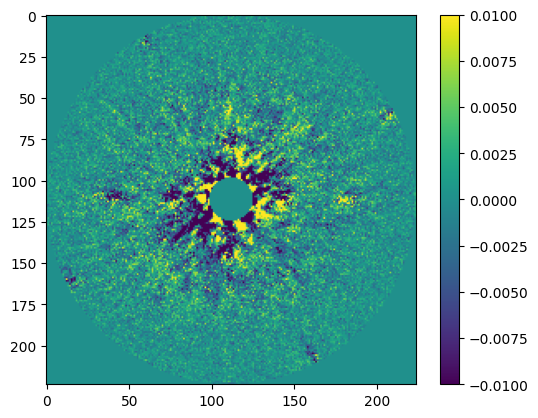

In [29]:
plt.imshow(sample_full_image,
           vmin=-0.01, vmax=0.01)
plt.colorbar()
